<a href="https://colab.research.google.com/github/FadilSadBoy20/Fadil-Insanus-Siddik_2411532013_ML2526/blob/main/Praktikum4/Latihan_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import library ynag diperlukan

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

Load dan split Dataset

In [8]:
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/Dataset/advertising.csv"
df = pd.read_csv(DATA_PATH)

X = df.drop("Sales", axis=1)
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Mounted at /content/drive


Scaling

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Uji minimal 5 nilai lambda baru

In [10]:
alphas = [0.0001, 0.005, 0.05, 0.5, 5, 50]

ridge_rmse = []
lasso_rmse = []

In [11]:
for a in alphas:
    r = Ridge(alpha=a).fit(X_train_scaled, y_train)
    l = Lasso(alpha=a).fit(X_train_scaled, y_train)

    ridge_rmse.append(np.sqrt(mean_squared_error(y_test, r.predict(X_test_scaled))))
    lasso_rmse.append(np.sqrt(mean_squared_error(y_test, l.predict(X_test_scaled))))

Grafik perubahan koefisien terhadap lambda

Ridge

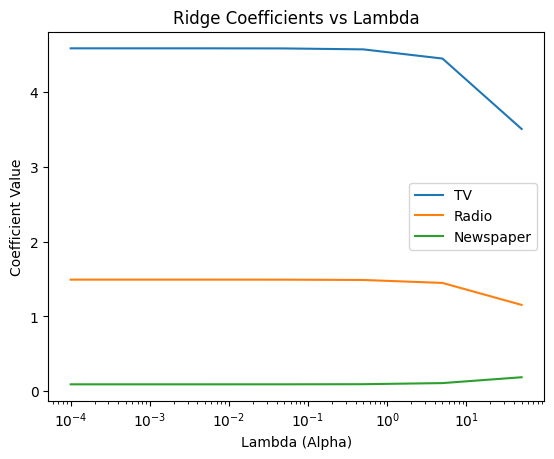

In [12]:
ridge_coefs = []

for a in alphas:
    model = Ridge(alpha=a)
    model.fit(X_train_scaled, y_train)
    ridge_coefs.append(model.coef_)

ridge_coefs = np.array(ridge_coefs)

for i in range(ridge_coefs.shape[1]):
    plt.plot(alphas, ridge_coefs[:, i], label=X.columns[i])

plt.xscale("log")
plt.xlabel("Lambda (Alpha)")
plt.ylabel("Coefficient Value")
plt.title("Ridge Coefficients vs Lambda")
plt.legend()
plt.show()

Lasso

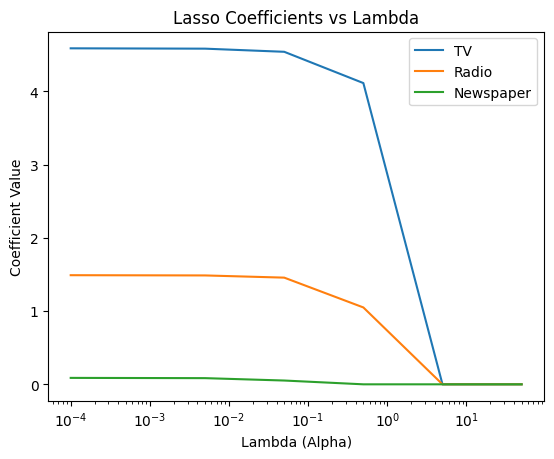

In [13]:
lasso_coefs = []

for a in alphas:
    model = Lasso(alpha=a)
    model.fit(X_train_scaled, y_train)
    lasso_coefs.append(model.coef_)

lasso_coefs = np.array(lasso_coefs)

for i in range(lasso_coefs.shape[1]):
    plt.plot(alphas, lasso_coefs[:, i], label=X.columns[i])

plt.xscale("log")
plt.xlabel("Lambda (Alpha)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Coefficients vs Lambda")
plt.legend()
plt.show()

Test lambda RMSE paling kecil

In [14]:
best_ridge_alpha = alphas[np.argmin(ridge_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_rmse)]

print("Best Ridge Alpha:", best_ridge_alpha)
print("Best Lasso Alpha:", best_lasso_alpha)

Best Ridge Alpha: 0.0001
Best Lasso Alpha: 0.005
